# Robot Navigation & Localization Anomaly Detection and Early Prediction
## Team 02 - Assignment 02

This notebook processes:
- `poses.csv` - Ground truth and estimated poses
- `behaviors.csv` - Behavior tree execution logs
- `rosbag2.csv` - Raw ROS topics (AMCL pose, transforms, velocity commands)
- `scenario.config` - Scenario parameters

## Table of Contents
1. [Setup & Imports](#1-setup--imports)
2. [Data Structures](#2-data-structures)
3. [Data Loading Module](#3-data-loading-module)
4. [Data Preprocessing Pipeline](#4-data-preprocessing-pipeline)
6. [Performance Metrics](#6-perfomance-metrics)
6. [Anomaly Detection System](#6-anomaly-detection-system)
7. [Load and Process Data](#7-load-and-process-data)
8. [Results Summary](#8-results-summary)
9. [Detailed Analysis & Visualization](#9-detailed-analysis--visualization)
    - [9.1 Metric distributions by outcome](#91-metric-distributions-by-outcome)
    - [9.2 Anomaly distribution by category](#92-anomaly-distribution-by-category)
    - [9.3 Anomaly correlation heatmap](#93-anomaly-correlation-heatmap)
    - [9.4 Sample trajectory visualization](#94-sample-trajectory-visualization)
10. [Early Anomaly Prediction](#10-early-anomaly-prediction-sensor--metric-pattern-analysis)
    - [10.1 Comprehensive Early Feature Extraction](#101-comprehensive-early-feature-extraction)
    - [10.2 Correlation Analysis](#102-correlation-analysis-early-features-vs-anomalies)
    - [10.3 Predictive Modeling](#103-predictive-modeling-early-anomaly-detection)
    - [10.4 Visualize Prediction Performance](#104-visualize-prediction-performance)
    - [10.5 Feature Importance Analysis](#105-feature-importance-analysis-coefficient-heatmap)
    - [10.6 Anomaly Co-occurrence Analysis](#106-anomaly-co-occurrence-analysis)
    - [10.7 Comprehensive Early Prediction Summary](#107-comprehensive-early-prediction-summary)

## 1. Setup & Imports

In [1]:
import warnings
from pathlib import Path
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional, Tuple

import ast
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import interpolate, stats
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

DATASET_PATH = Path('ws25_aia_complete_data')
IMAGES_PATH = Path('images')
IMAGES_PATH.mkdir(exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

# (Important when the notebook uses a dark theme: otherwise axes can look "missing".)
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'savefig.edgecolor': 'white',
    'savefig.transparent': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'text.color': 'black',
    'grid.color': '#d0d0d0',
    'axes.spines.top': True,
    'axes.spines.right': True,
    'axes.spines.left': True,
    'axes.spines.bottom': True,
})

# Ensure inline plots in the notebook have a white background (fixes GitLab dark mode visibility)
try:
    from IPython import get_ipython
    ipython = get_ipython()
    if ipython:
        ipython.run_line_magic('config', "InlineBackend.print_figure_kwargs = {'facecolor' : 'w'}")
except Exception:
    pass


SAVEFIG_KW = dict(facecolor='white', edgecolor='white', transparent=False)

print(f'Dataset path exists: {DATASET_PATH.exists()}')

Dataset path exists: True


## 2. Data Structures

In [2]:
@dataclass
class ScenarioConfig:
    """Scenario configuration parameters."""
    goal_poses: List[Dict]
    start_pose: Dict
    laser_noise_std: float
    laser_drop_pct: float
    map_file: str

@dataclass
class AMCLData:
    """AMCL localization data from rosbag2.csv."""
    timestamps: np.ndarray  # seconds
    positions: np.ndarray   # (N, 3) x, y, z
    orientations: np.ndarray  # (N, 4) w, x, y, z quaternion
    covariances: List[np.ndarray]  # List of 6x6 covariance matrices

@dataclass
class RunMetrics:
    """Computed metrics for a single run."""
    mean_pos_error: float = 0.0
    rmse_pos: float = 0.0
    mean_yaw_error: float = 0.0
    path_efficiency: float = 0.0
    mean_linear_velocity: float = 0.0
    mean_angular_velocity: float = 0.0
    trajectory_smoothness: float = 0.0
    duration: float = 0.0
    mean_amcl_uncertainty: float = 0.0

@dataclass
class RunData:
    """Complete data for a single simulation run."""
    scenario_name: str
    run_id: int
    run_path: Path
    scenario_category: str = ''
    outcome: str = 'unknown'
    poses_df: Optional[pd.DataFrame] = None
    behaviors_df: Optional[pd.DataFrame] = None
    rosbag_df: Optional[pd.DataFrame] = None  # NEW: rosbag2.csv data
    amcl_data: Optional[AMCLData] = None  # NEW: Parsed AMCL data
    config: Optional[ScenarioConfig] = None
    synced_data: Optional[pd.DataFrame] = None
    metrics: Optional[RunMetrics] = None
    anomalies: List[str] = field(default_factory=list)
    time_series_metrics: Optional[pd.DataFrame] = None
    is_valid: bool = True
    error_msg: str = ''

## 3. Data Loading Module

In [3]:
class DatasetLoader:
    """Handles loading and parsing of all dataset files including rosbag2.csv."""
    
    CATEGORY_PATTERNS = {
        'door-width': r'door-width|door-size',
        'room-size': r'room-size',
        'hallway-window': r'hallway-window',
        'everything-failure': r'everything-failure',
        'floorplan-failure': r'floorplan-failure'
    }
    
    def __init__(self, dataset_path: Path):
        self.dataset_path = dataset_path
        
    def get_scenario_category(self, scenario_name: str) -> str:
        import re
        for cat, pattern in self.CATEGORY_PATTERNS.items():
            if re.search(pattern, scenario_name, re.IGNORECASE):
                return cat
        return 'other'
    
    def parse_scenario_config(self, config_path: Path) -> Optional[ScenarioConfig]:
        try:
            with open(config_path, 'r') as f:
                data = yaml.safe_load(f)
            ts = data.get('test_scenario', {})
            return ScenarioConfig(
                goal_poses=ts.get('goal_poses', []),
                start_pose=ts.get('start_pose', {}),
                laser_noise_std=float(ts.get('laserscan_gaussian_noise_std_deviation', 0.02)),
                laser_drop_pct=float(ts.get('laserscan_random_drop_percentage', 0.0)),
                map_file=ts.get('map_file', '')
            )
        except Exception:
            return None
    
    def parse_amcl_data(self, rosbag_df: pd.DataFrame) -> Optional[AMCLData]:
        """Extract AMCL pose data with uncertainty from rosbag2.csv."""
        if rosbag_df is None or rosbag_df.empty:
            return None
        amcl_rows = rosbag_df[rosbag_df['topic'] == '/amcl_pose']
        if amcl_rows.empty:
            return None
        try:
            timestamps = (amcl_rows['timestamp'].values / 1e9).astype(float)
            positions = np.column_stack([
                amcl_rows['pose.pose.position.x'].values,
                amcl_rows['pose.pose.position.y'].values,
                amcl_rows['pose.pose.position.z'].fillna(0).values
            ])
            orientations = np.column_stack([
                amcl_rows['pose.pose.orientation.w'].values,
                amcl_rows['pose.pose.orientation.x'].values,
                amcl_rows['pose.pose.orientation.y'].values,
                amcl_rows['pose.pose.orientation.z'].values
            ])
            # Parse covariance matrices with improved handling
            covariances = []
            for cov_val in amcl_rows['pose.covariance'].values:
                try:
                    if cov_val is None or (isinstance(cov_val, float) and np.isnan(cov_val)):
                        covariances.append(np.eye(6) * 0.01)
                        continue
                    
                    if isinstance(cov_val, str):
                        # Clean string and parse
                        cov_str = cov_val.replace('\n', ' ').replace('[', '').replace(']', '')
                        cov_arr = np.fromstring(cov_str, sep=' ')
                        if len(cov_arr) != 36:
                            # Try comma separation
                            cov_arr = np.fromstring(cov_str, sep=',')
                        if len(cov_arr) != 36:
                            # Try ast.literal_eval as fallback
                            cov_arr = np.array(ast.literal_eval(cov_val.replace('\n', ' ')))
                    elif isinstance(cov_val, (list, np.ndarray)):
                        cov_arr = np.array(cov_val).flatten()
                    else:
                        covariances.append(np.eye(6) * 0.01)
                        continue
                    
                    if len(cov_arr) == 36:
                        cov_matrix = cov_arr.reshape(6, 6)
                        # Validate: covariance diagonal should be non-negative
                        if np.all(np.diag(cov_matrix) >= 0):
                            covariances.append(cov_matrix)
                        else:
                            covariances.append(np.eye(6) * 0.01)
                    else:
                        covariances.append(np.eye(6) * 0.01)
                except Exception:
                    covariances.append(np.eye(6) * 0.01)
            
            return AMCLData(timestamps=timestamps, positions=positions, 
                           orientations=orientations, covariances=covariances)
        except Exception as e:
            return None
    
    def get_run_outcome(self, behaviors_df: pd.DataFrame) -> str:
        if behaviors_df is None or behaviors_df.empty:
            return 'no_data'
        nav = behaviors_df[behaviors_df['behavior_name'].str.contains('nav_through_poses', na=False)]
        if nav.empty:
            return 'no_navigation'
        last_status = nav.iloc[-1]['status_name']
        return 'success' if last_status == 'SUCCESS' else ('failure' if last_status == 'FAILURE' else 'incomplete')
    
    def load_run(self, run_path: Path, scenario_name: str, run_id: int) -> RunData:
        run = RunData(scenario_name=scenario_name, run_id=run_id, run_path=run_path,
                      scenario_category=self.get_scenario_category(scenario_name))
        # Load poses.csv
        poses_path = run_path / 'poses.csv'
        if poses_path.exists():
            try:
                run.poses_df = pd.read_csv(poses_path)
                if run.poses_df.empty:
                    run.is_valid = False
                    run.error_msg = 'Empty poses.csv'
            except Exception as e:
                run.is_valid = False
                run.error_msg = f'Poses error: {e}'
        else:
            run.is_valid = False
            run.error_msg = 'Missing poses.csv'
        # Load behaviors.csv
        behaviors_path = run_path / 'behaviors.csv'
        if behaviors_path.exists():
            try:
                run.behaviors_df = pd.read_csv(behaviors_path)
            except Exception:
                pass
        # Load rosbag2.csv (NEW)
        rosbag_path = run_path / 'rosbag2.csv'
        if rosbag_path.exists():
            try:
                run.rosbag_df = pd.read_csv(rosbag_path, low_memory=False)
                run.amcl_data = self.parse_amcl_data(run.rosbag_df)
            except Exception:
                pass
        # Load config
        config_path = run_path / 'scenario.config'
        if config_path.exists():
            run.config = self.parse_scenario_config(config_path)
        run.outcome = self.get_run_outcome(run.behaviors_df)
        return run
    
    def load_all_runs(self, max_scenarios: int = None) -> List[RunData]:
        runs = []
        scenario_dirs = sorted([d for d in self.dataset_path.iterdir() if d.is_dir()])
        if max_scenarios:
            scenario_dirs = scenario_dirs[:max_scenarios]
        for scenario_dir in tqdm(scenario_dirs, desc='Loading scenarios'):
            scenario_name = scenario_dir.name
            run_dirs = sorted([d for d in scenario_dir.iterdir() if d.is_dir() and d.name.isdigit()])
            for run_dir in run_dirs:
                run = self.load_run(run_dir, scenario_name, int(run_dir.name))
                runs.append(run)
        return runs

loader = DatasetLoader(DATASET_PATH)
print('Loader initialized with rosbag2 support')

Loader initialized with rosbag2 support


## 4. Data Preprocessing Pipeline

In [4]:
class DataPreprocessor:
    """Handles data synchronization and preprocessing."""
    
    @staticmethod
    def normalize_yaw(yaw: np.ndarray) -> np.ndarray:
        return np.arctan2(np.sin(yaw), np.cos(yaw))
    
    @staticmethod
    def quaternion_to_yaw(w, x, y, z):
        """Convert quaternion to yaw angle."""
        siny_cosp = 2 * (w * z + x * y)
        cosy_cosp = 1 - 2 * (y * y + z * z)
        return np.arctan2(siny_cosp, cosy_cosp)
    
    @staticmethod
    def sync_poses(poses_df: pd.DataFrame) -> Optional[pd.DataFrame]:
        if poses_df is None or poses_df.empty:
            return None
        gt_df = poses_df[poses_df['frame'] == 'nav2_turtlebot4_base_link_gt'].copy()
        est_df = poses_df[poses_df['frame'] == 'base_link'].copy()
        if gt_df.empty or est_df.empty:
            return None
        gt_df = gt_df.sort_values('timestamp').drop_duplicates('timestamp')
        est_df = est_df.sort_values('timestamp').drop_duplicates('timestamp')
        est_times = est_df['timestamp'].values
        gt_times = gt_df['timestamp'].values
        if len(gt_times) < 2:
            return None
        valid_mask = (est_times >= gt_times.min()) & (est_times <= gt_times.max())
        est_df = est_df[valid_mask]
        if len(est_df) < 2:
            return None
        synced = est_df.copy()
        synced = synced.rename(columns={'position.x': 'est_x', 'position.y': 'est_y', 'orientation.yaw': 'est_yaw'})
        for col, new_col in [('position.x', 'gt_x'), ('position.y', 'gt_y'), ('orientation.yaw', 'gt_yaw')]:
            f = interpolate.interp1d(gt_times, gt_df[col].values, kind='linear', fill_value='extrapolate')
            synced[new_col] = f(synced['timestamp'].values)
        synced['gt_yaw'] = DataPreprocessor.normalize_yaw(synced['gt_yaw'].values)
        synced['est_yaw'] = DataPreprocessor.normalize_yaw(synced['est_yaw'].values)
        synced = synced[['timestamp', 'est_x', 'est_y', 'est_yaw', 'gt_x', 'gt_y', 'gt_yaw']]
        return synced.reset_index(drop=True)
    
    @staticmethod
    def filter_stationary(synced_df: pd.DataFrame, velocity_threshold: float = 0.01) -> pd.DataFrame:
        if synced_df is None or len(synced_df) < 3:
            return synced_df
        dx = np.diff(synced_df['est_x'].values)
        dy = np.diff(synced_df['est_y'].values)
        dt = np.diff(synced_df['timestamp'].values)
        dt = np.where(dt == 0, 1e-6, dt)
        velocity = np.sqrt(dx**2 + dy**2) / dt
        velocity = np.concatenate([[velocity[0]], velocity])
        moving_mask = velocity > velocity_threshold
        first_moving = np.argmax(moving_mask)
        last_moving = len(moving_mask) - np.argmax(moving_mask[::-1]) - 1
        return synced_df.iloc[first_moving:last_moving+1].reset_index(drop=True)
    
    def preprocess(self, run: RunData, filter_stationary: bool = True) -> RunData:
        if not run.is_valid:
            return run
        synced = self.sync_poses(run.poses_df)
        if synced is None or len(synced) < 10:
            run.is_valid = False
            run.error_msg = 'Sync failed'
            return run
        if filter_stationary:
            synced = self.filter_stationary(synced)
        if synced is None or len(synced) < 5:
            run.is_valid = False
            run.error_msg = 'Too few points after filtering'
            return run
        run.synced_data = synced
        return run

preprocessor = DataPreprocessor()
print('Preprocessor initialized')

Preprocessor initialized


## 6. Perfomance Metrics

#### Localization accuracy (position)
1. **mean_pos_error** *(meters, m)*  
   - **Definition:** Average Euclidean distance between estimated and ground-truth positions.  
   - **Computed as:** mean of `sqrt((est_x-gt_x)^2 + (est_y-gt_y)^2)` over all synced timestamps.  
   - **Interpretation:** Lower is better.

2. **rmse_pos** *(m)*  
   - **Definition:** Root mean square of position error (penalizes large errors more than mean).  
   - **Computed as:** `sqrt(mean(pos_error^2))`.  
   - **Interpretation:** Lower is better; sensitive to spikes.

#### Localization accuracy (orientation)
3. **mean_yaw_error** *(radians, rad)*  
   - **Definition:** Average absolute yaw difference between estimate and ground truth.  
   - **Computed as:** mean of `abs(wrap_to_pi(est_yaw - gt_yaw))`.  
   - **Interpretation:** Lower is better.

#### Path geometry & efficiency

4. **path_efficiency** *(unitless ratio)*  
   - **Definition:** How direct the executed motion is relative to ground truth.  
   - **Computed as:** `gt_path / executed_path` (0 if executed length is 0).  
   - **Interpretation:** Closer to 1 is better; low values suggest detours.

#### Kinematics & smoothness
5. **mean_linear_velocity** *(m/s)*  
   - **Definition:** Mean translational speed derived from estimated motion.  
   - **Computed as:** mean of `sqrt(dx^2+dy^2)/dt`.  
   - **Interpretation:** Context for speed-vs-accuracy tradeoffs.

6. **trajectory_smoothness** *(rad/s²)*  
   - **Definition:** Average absolute angular acceleration magnitude.  
   - **Computed as:** mean of `abs(diff(angular_vel)/dt)` (with safe handling for zero dt).  
   - **Interpretation:** Lower is smoother; higher implies oscillation/jerky turning.

7. **duration** *(seconds, s)*  
   - **Definition:** Total time span of the synced segment.  
   - **Computed as:** `timestamp_last - timestamp_first`.

#### AMCL uncertainty 
8. **mean_amcl_uncertainty** *(meters-equivalent, m)*  
   - **Definition:** Average positional uncertainty proxy from AMCL covariance.  
   - **Computed as:** for each covariance `cov`, use `sqrt(cov[0,0] + cov[1,1])`, then take the mean.  
   - **Interpretation:** Higher values indicate less confident localization.

In [5]:
class MetricCalculator:
    """Computes performance metrics including AMCL uncertainty."""
    
    @staticmethod
    def compute_position_error(synced: pd.DataFrame) -> np.ndarray:
        return np.sqrt((synced['est_x'] - synced['gt_x'])**2 + (synced['est_y'] - synced['gt_y'])**2)
    
    @staticmethod
    def compute_yaw_error(synced: pd.DataFrame) -> np.ndarray:
        diff = synced['est_yaw'] - synced['gt_yaw']
        return np.abs(np.arctan2(np.sin(diff), np.cos(diff)))
    
    @staticmethod
    def compute_path_length(x: np.ndarray, y: np.ndarray) -> float:
        return float(np.sum(np.sqrt(np.diff(x)**2 + np.diff(y)**2)))
    
    @staticmethod
    def compute_velocities(synced: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray]:
        t = synced['timestamp'].values
        dt = np.diff(t)
        dt = np.where(dt == 0, 1e-6, dt)
        dx = np.diff(synced['est_x'].values)
        dy = np.diff(synced['est_y'].values)
        dyaw = np.diff(synced['est_yaw'].values)
        dyaw = np.arctan2(np.sin(dyaw), np.cos(dyaw))
        linear_vel = np.sqrt(dx**2 + dy**2) / dt
        angular_vel = np.abs(dyaw) / dt
        return linear_vel, angular_vel
    
    @staticmethod
    def compute_trajectory_smoothness(angular_vel: np.ndarray, dt: np.ndarray) -> float:
        if len(angular_vel) < 2:
            return 0.0
        dt_safe = np.where(dt[:-1] == 0, 1e-6, dt[:-1]) if len(dt) > len(angular_vel)-1 else dt
        angular_acc = np.diff(angular_vel) / dt_safe[:len(angular_vel)-1]
        return float(np.mean(np.abs(angular_acc)))
    
    @staticmethod
    def compute_amcl_uncertainty(amcl_data: Optional[AMCLData]) -> float:
        """Compute mean positional uncertainty from AMCL covariance.
        
        Uses sqrt of sum of x,y variances (diagonal elements 0,0 and 1,1).
        This represents the 1-sigma positional uncertainty ellipse size.
        """
        if amcl_data is None or not amcl_data.covariances:
            return 0.0
        
        uncertainties = []
        for cov in amcl_data.covariances:
            try:
                if cov is None or not isinstance(cov, np.ndarray):
                    continue
                if cov.shape != (6, 6):
                    continue
                
                # Extract x and y variances (diagonal elements)
                var_x = cov[0, 0]
                var_y = cov[1, 1]
                
                # Skip invalid values
                if not (np.isfinite(var_x) and np.isfinite(var_y)):
                    continue
                if var_x < 0 or var_y < 0:
                    continue
                
                # Positional uncertainty: sqrt of sum of variances
                # This is the "circular error probable" approximation
                pos_uncertainty = np.sqrt(var_x + var_y)
                
                # Additional sanity check: uncertainty should be reasonable (< 100m)
                if pos_uncertainty < 100.0:
                    uncertainties.append(pos_uncertainty)
            except Exception:
                continue
        
        if not uncertainties:
            return 0.0
        
        return float(np.mean(uncertainties))
    
    def compute_time_series(self, synced: pd.DataFrame) -> pd.DataFrame:
        pos_error = self.compute_position_error(synced)
        yaw_error = self.compute_yaw_error(synced)
        linear_vel, angular_vel = self.compute_velocities(synced)
        ts = pd.DataFrame({
            'timestamp': synced['timestamp'].values,
            'pos_error': pos_error,
            'yaw_error': yaw_error
        })
        ts['linear_vel'] = np.concatenate([[linear_vel[0]], linear_vel])
        ts['angular_vel'] = np.concatenate([[angular_vel[0]], angular_vel])
        return ts
    
    def compute_metrics(self, run: RunData) -> RunData:
        if not run.is_valid or run.synced_data is None:
            return run
        synced = run.synced_data
        pos_error = self.compute_position_error(synced)
        yaw_error = self.compute_yaw_error(synced)
        linear_vel, angular_vel = self.compute_velocities(synced)
        executed_path = self.compute_path_length(synced['est_x'].values, synced['est_y'].values)
        gt_path = self.compute_path_length(synced['gt_x'].values, synced['gt_y'].values)
        dt = np.diff(synced['timestamp'].values)
        mean_amcl = self.compute_amcl_uncertainty(run.amcl_data)
        run.metrics = RunMetrics(
            mean_pos_error=float(np.mean(pos_error)),
            rmse_pos=float(np.sqrt(np.mean(pos_error**2))),
            mean_yaw_error=float(np.mean(yaw_error)),
            path_efficiency=gt_path / executed_path if executed_path > 0 else 0,
            mean_linear_velocity=float(np.mean(linear_vel)),
            mean_angular_velocity=float(np.mean(angular_vel)),
            trajectory_smoothness=self.compute_trajectory_smoothness(angular_vel, dt),
            duration=float(synced['timestamp'].iloc[-1] - synced['timestamp'].iloc[0]),
            mean_amcl_uncertainty=mean_amcl
        )
        run.time_series_metrics = self.compute_time_series(synced)
        return run

metric_calculator = MetricCalculator()
print('Metric calculator initialized with AMCL uncertainty')

Metric calculator initialized with AMCL uncertainty


## 6. Anomaly Detection System


### 1) Rule-based anomalies — `RuleBasedAnomalyDetector`

1. **goal_failure**  
   - **Triggered when:** behavior outcome indicates navigation ended in failure (`outcome == 'failure'`).  
   - **Purpose:** Separates explicit task failure from degraded-but-successful runs.

2. **no_initiation**  
   - **Triggered when:** no behavior data or no navigation behavior present (`outcome in {'no_data','no_navigation'}`).  
   - **Purpose:** Captures missing logs / navigation never started.

3. **position_error_spike**  
   - **Triggered when:** position error exceeds a global threshold for *K* consecutive frames.  
   - **Threshold:** `global_mean + pos_error_sigma * global_std` computed across all valid runs’ `pos_error`.  
   - **Consecutive requirement:** `consecutive_frames` (default 3).  
   - **Purpose:** Detects sustained localization divergence, not single-point noise.

4. **stuck**  
   - **Triggered when:** `linear_vel < velocity_threshold` continuously for longer than `duration_threshold`.  
   - **Defaults:** `velocity_threshold=0.01 m/s`, `duration_threshold=5.0 s`.  
   - **Purpose:** Detects immobilization / inability to progress.

5. **high_amcl_uncertainty**  
   - **Triggered when:** `mean_amcl_uncertainty > threshold`.  
   - **Default:** `threshold=0.5` (using the notebook’s uncertainty proxy).  
   - **Purpose:** Flags runs where AMCL reports persistently poor confidence.

6. **high_yaw_error**  
   - **Triggered when:** `mean_yaw_error > 0.5 rad`.  
   - **Purpose:** Detects runs with poor orientation tracking.

7. **path_inefficiency**  
   - **Triggered when:** `path_efficiency < 0.6`.  
   - **Purpose:** Flags excessive detours or "wandering" behavior.

8. **oscillation**  
   - **Triggered when:** `trajectory_smoothness > 2.0`.  
   - **Purpose:** Detects jerky motion or control instability.

---

### 2) Isolation Forest — `MLAnomalyDetector` (ML Based Anomaly)

9. **Isolation Forest**  
   - **Triggered when:** Isolation Forest predicts the run as an outlier (`-1`) in standardized feature space.  
   - **Features used (exact list, in order):**  
     1) mean_pos_error  
     2) rmse_pos  
     4) mean_yaw_error  
     5) duration  
     6) path_efficiency  
     7) mean_linear_velocity  
     8) trajectory_smoothness  
     9) mean_amcl_uncertainty  

   - **Note:** Model is only fitted if enough valid runs exist (guarded in code).  
   - **Purpose:** Captures multi-metric abnormal patterns that rules may miss.

In [6]:
class RuleBasedAnomalyDetector:
    """Rule-based anomaly detection using multiple data sources."""
    
    def __init__(self, pos_error_sigma: float = 3.0, consecutive_frames: int = 3):
        self.pos_error_sigma = pos_error_sigma
        self.consecutive_frames = consecutive_frames
        self.global_pos_error_stats = None
    
    def compute_global_stats(self, runs: List[RunData]):
        all_errors = []
        for run in runs:
            if run.is_valid and run.time_series_metrics is not None:
                all_errors.extend(run.time_series_metrics['pos_error'].values)
        if all_errors:
            self.global_pos_error_stats = {'mean': np.mean(all_errors), 'std': np.std(all_errors)}
    
    def detect_goal_failure(self, run: RunData) -> bool:
        return run.outcome == 'failure'
    
    def detect_no_initiation(self, run: RunData) -> bool:
        return run.outcome == 'no_data' or run.outcome == 'no_navigation'
    
    def detect_position_error_spike(self, run: RunData) -> bool:
        if not run.is_valid or run.time_series_metrics is None or self.global_pos_error_stats is None:
            return False
        threshold = self.global_pos_error_stats['mean'] + self.pos_error_sigma * self.global_pos_error_stats['std']
        errors = run.time_series_metrics['pos_error'].values
        above_threshold = errors > threshold
        for i in range(len(above_threshold) - self.consecutive_frames + 1):
            if all(above_threshold[i:i+self.consecutive_frames]):
                return True
        return False
    
    def detect_stuck(self, run: RunData, velocity_threshold: float = 0.01, duration_threshold: float = 5.0) -> bool:
        if not run.is_valid or run.time_series_metrics is None:
            return False
        ts = run.time_series_metrics
        stuck_mask = ts['linear_vel'] < velocity_threshold
        start = None
        for i, is_stuck in enumerate(stuck_mask):
            if is_stuck and start is None:
                start = ts['timestamp'].iloc[i]
            elif not is_stuck and start is not None:
                duration = ts['timestamp'].iloc[i] - start
                if duration > duration_threshold:
                    return True
                start = None
        return False
    
    def detect_high_amcl_uncertainty(self, run: RunData, threshold: float = 0.5) -> bool:
        """Detect high localization uncertainty from AMCL."""
        if run.metrics is None:
            return False
        return run.metrics.mean_amcl_uncertainty > threshold
    
    def detect_high_yaw_error(self, run: RunData, threshold: float = 0.5) -> bool:
        return run.metrics.mean_yaw_error > threshold if run.metrics else False

    def detect_path_inefficiency(self, run: RunData, threshold: float = 0.6) -> bool:
        return run.metrics.path_efficiency < threshold if run.metrics else False

    def detect_oscillation(self, run: RunData, threshold: float = 2.0) -> bool:
        return run.metrics.trajectory_smoothness > threshold if run.metrics else False
    
    def detect_all(self, run: RunData) -> List[str]:
        anomalies = []
        if self.detect_goal_failure(run):
            anomalies.append('goal_failure')
        if self.detect_no_initiation(run):
            anomalies.append('no_initiation')
        if self.detect_position_error_spike(run):
            anomalies.append('position_error_spike')
        if self.detect_stuck(run):
            anomalies.append('stuck')
        if self.detect_high_amcl_uncertainty(run):
            anomalies.append('high_amcl_uncertainty')
        if self.detect_high_yaw_error(run):
            anomalies.append('high_yaw_error')
        if self.detect_path_inefficiency(run):
            anomalies.append('path_inefficiency')
        if self.detect_oscillation(run):
            anomalies.append('oscillation')
        return anomalies

class MLAnomalyDetector:
    """ML-based anomaly detection using Isolation Forest."""
    
    def __init__(self, contamination: float = 0.1):
        self.contamination = contamination
        self.model = IsolationForest(contamination=contamination, random_state=42, n_estimators=100)
        self.scaler = StandardScaler()
        self.is_fitted = False
    
    def extract_features(self, run: RunData) -> Optional[np.ndarray]:
        if not run.is_valid or run.metrics is None:
            return None
        m = run.metrics
        return np.array([
            m.mean_pos_error, m.rmse_pos, m.mean_yaw_error,
            m.duration, m.path_efficiency,
            m.mean_linear_velocity, m.trajectory_smoothness,
            m.mean_amcl_uncertainty
        ])
    
    def fit(self, runs: List[RunData]):
        features = [self.extract_features(r) for r in runs if r.is_valid and r.metrics is not None]
        features = [f for f in features if f is not None]
        if len(features) < 10:
            return
        X = np.vstack(features)
        X_scaled = self.scaler.fit_transform(X)
        self.model.fit(X_scaled)
        self.is_fitted = True
    
    def predict(self, run: RunData) -> bool:
        if not self.is_fitted:
            return False
        features = self.extract_features(run)
        if features is None:
            return False
        X_scaled = self.scaler.transform(features.reshape(1, -1))
        return self.model.predict(X_scaled)[0] == -1

rule_detector = RuleBasedAnomalyDetector()
ml_detector = MLAnomalyDetector(contamination=0.15)
print('Anomaly detectors initialized with AMCL-based detection')

Anomaly detectors initialized with AMCL-based detection


## 7. Load and Process Data

In [7]:
# Load all runs
print('Loading dataset (this may take a few minutes)...')
all_runs = loader.load_all_runs(max_scenarios=100)  # Set to e.g. 50 for faster processing
print(f'Loaded {len(all_runs)} total runs')

# Count runs with rosbag data
runs_with_rosbag = sum(1 for r in all_runs if r.rosbag_df is not None)
runs_with_amcl = sum(1 for r in all_runs if r.amcl_data is not None)
print(f'Runs with rosbag2.csv: {runs_with_rosbag}')
print(f'Runs with parsed AMCL data: {runs_with_amcl}')

# Preprocess
print('\nPreprocessing...')
for run in tqdm(all_runs, desc='Preprocessing'):
    preprocessor.preprocess(run)

valid_runs = [r for r in all_runs if r.is_valid]
print(f'Valid runs after preprocessing: {len(valid_runs)}')

# Compute metrics
print('\nComputing metrics...')
for run in tqdm(valid_runs, desc='Computing metrics'):
    metric_calculator.compute_metrics(run)

# Anomaly detection
print('\nDetecting anomalies...')
rule_detector.compute_global_stats(valid_runs)
ml_detector.fit(valid_runs)

for run in valid_runs:
    run.anomalies = rule_detector.detect_all(run)
    if ml_detector.predict(run):
        run.anomalies.append('Isolation Forest')

print('\n✅ Processing complete!')

Loading dataset (this may take a few minutes)...


Loading scenarios:   0%|          | 0/100 [00:00<?, ?it/s]

Loaded 300 total runs
Runs with rosbag2.csv: 300
Runs with parsed AMCL data: 300

Preprocessing...


Preprocessing:   0%|          | 0/300 [00:00<?, ?it/s]

Valid runs after preprocessing: 300

Computing metrics...


Computing metrics:   0%|          | 0/300 [00:00<?, ?it/s]


Detecting anomalies...

✅ Processing complete!


## 8. Results Summary

In [8]:
# Create summary DataFrame with AMCL metrics
summary_data = []
for run in valid_runs:
    if run.metrics:
        m = run.metrics
        summary_data.append({
            'scenario': run.scenario_name,
            'run_id': run.run_id,
            'category': run.scenario_category,
            'outcome': run.outcome,
            'mean_pos_error': m.mean_pos_error,
            'rmse_pos': m.rmse_pos,
            'mean_yaw_error': m.mean_yaw_error,
            'duration': m.duration,
            'path_efficiency': m.path_efficiency,
            'mean_velocity': m.mean_linear_velocity,
            'smoothness': m.trajectory_smoothness,
            'amcl_uncertainty': m.mean_amcl_uncertainty,
            'anomaly_count': len(run.anomalies),
            'anomalies': ','.join(run.anomalies) if run.anomalies else 'none'
        })

summary_df = pd.DataFrame(summary_data)
print(f'Summary DataFrame: {len(summary_df)} runs')
print('\nOutcome distribution:')
print(summary_df['outcome'].value_counts())
print('\nCategory distribution:')
print(summary_df['category'].value_counts())
print('\nFirst 10 runs:')
summary_df.head(10)

Summary DataFrame: 300 runs

Outcome distribution:
outcome
failure       150
success       141
incomplete      9
Name: count, dtype: int64

Category distribution:
category
door-width        120
hallway-window    120
room-size          60
Name: count, dtype: int64

First 10 runs:


,scenario,run_id,category,outcome,mean_pos_error,rmse_pos,mean_yaw_error,duration,path_efficiency,mean_velocity,smoothness,amcl_uncertainty,anomaly_count,anomalies
0,small-dataset-maps-0-3-door-width-1f1-1,0,door-width,failure,0.030531,0.032783,0.035955,12.780,0.734568,0.034172,0.485437,0.197962,1,goal_failure
1,small-dataset-maps-0-3-door-width-1f1-1,1,door-width,failure,0.028770,0.029987,0.035155,12.204,0.782961,0.034182,0.523786,0.212642,1,goal_failure
2,small-dataset-maps-0-3-door-width-1f1-1,2,door-width,failure,0.014917,0.017303,0.037295,12.204,0.752275,0.035015,0.460603,0.207399,1,goal_failure
3,small-dataset-maps-0-33-door-width-1f1-2,0,door-width,failure,0.039765,0.042165,0.051867,12.384,0.718107,0.035986,0.417989,0.208331,1,goal_failure
4,small-dataset-maps-0-33-door-width-1f1-2,1,door-width,failure,0.024151,0.025029,0.043916,12.204,0.759025,0.034632,0.627144,0.199001,1,goal_failure
5,small-dataset-maps-0-33-door-width-1f1-2,2,door-width,failure,0.040881,0.042126,0.040897,11.484,0.736545,0.038504,0.621034,0.198494,1,goal_failure
6,small-dataset-maps-0-36-door-width-1f1-3,0,door-width,failure,0.029375,0.030969,0.040551,30.492,0.967517,0.189586,0.492561,0.336633,2,"goal_failure,stuck"
7,small-dataset-maps-0-36-door-width-1f1-3,1,door-width,failure,0.067182,0.072472,0.031046,28.404,0.962131,0.207257,0.570935,0.337670,1,goal_failure
8,small-dataset-maps-0-36-door-width-1f1-3,2,door-width,failure,0.036788,0.040208,0.037461,31.824,0.965607,0.187997,0.502171,0.354580,2,"goal_failure,stuck"
9,small-dataset-maps-0-44-door-width-1f1-4,0,door-width,failure,0.043892,0.049549,0.030980,29.631,0.904873,0.103282,0.602232,0.265336,1,goal_failure


## 9. Detailed Analysis & Visualization

### 9.1 Metric distributions by outcome

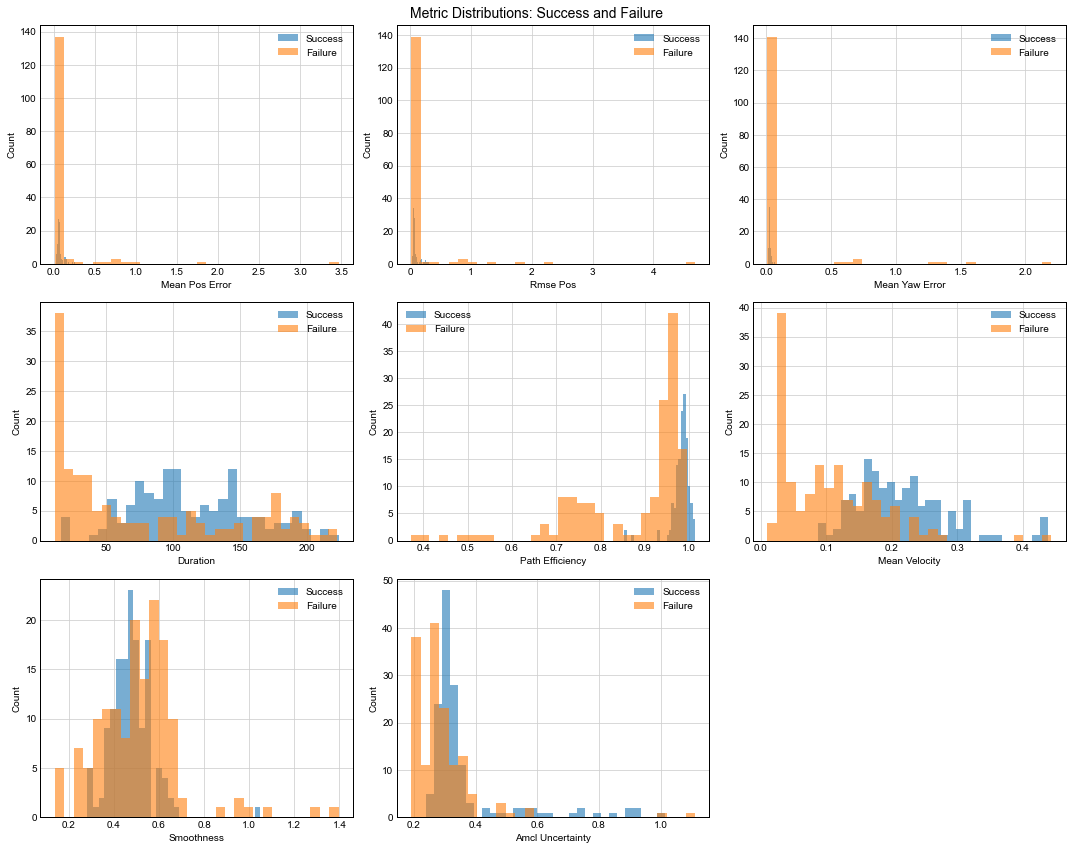

In [10]:

metrics_to_plot = ['mean_pos_error', 'rmse_pos', 'mean_yaw_error','duration','path_efficiency','mean_velocity','smoothness','amcl_uncertainty']
rows = (len(metrics_to_plot) + 2) // 3
fig, axes = plt.subplots(rows, 3, figsize=(15, 4 * rows))

for ax, metric in zip(axes.flat, metrics_to_plot):
    for outcome in ['success', 'failure']:
        data = summary_df[summary_df['outcome'] == outcome][metric].dropna()
        if len(data) > 0:
            ax.hist(data, bins=30, alpha=0.6, label=outcome.capitalize())
    ax.set_xlabel(metric.replace('_', ' ').title())
    ax.set_ylabel('Count')
    ax.legend()

# Hide unused subplots
for i in range(len(metrics_to_plot), rows * 3):
    axes.flat[i].set_visible(False)

plt.suptitle('Metric Distributions: Success and Failure', fontsize=14)
plt.tight_layout()
plt.savefig(IMAGES_PATH / 'metric_distributions.png', dpi=150, **SAVEFIG_KW)
plt.show()

### 9.2 Anomaly distribution by category

Anomalies with zero occurrences (reason: not triggered in any run): ['no_initiation', 'oscillation']


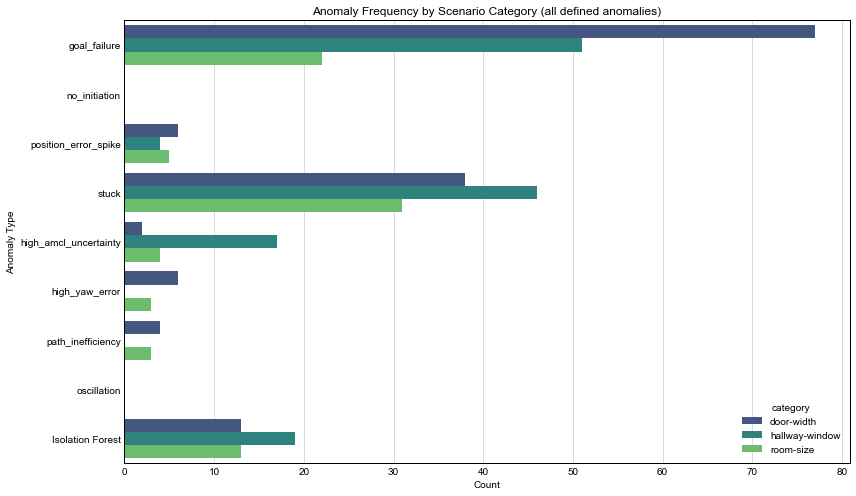

In [11]:

ANOM_LABELS = [
    'goal_failure',
    'no_initiation',
    'position_error_spike',
    'stuck',
    'high_amcl_uncertainty',
    'high_yaw_error',
    'path_inefficiency',
    'oscillation',
    'Isolation Forest'
]

anomaly_data = []
for run in valid_runs:
    for a in run.anomalies:
        anomaly_data.append({'category': run.scenario_category, 'anomaly': a})

if anomaly_data:
    df_anom = pd.DataFrame(anomaly_data)
    categories = sorted(df_anom['category'].unique())
    df_counts = df_anom.value_counts(['anomaly', 'category']).reset_index(name='count')

    # ensure every anomaly/category combo exists (zero if missing)
    grid = pd.DataFrame(
        [{'anomaly': a, 'category': c} for a in ANOM_LABELS for c in categories]
    )
    df_counts = (grid.merge(df_counts, on=['anomaly', 'category'], how='left')
                       .fillna({'count': 0}))

    missing_anoms = [a for a in ANOM_LABELS if df_counts[df_counts['anomaly'] == a]['count'].sum() == 0]
    if missing_anoms:
        print('Anomalies with zero occurrences (reason: not triggered in any run):', missing_anoms)
    else:
        print('All nine anomalies are represented in the data.')

    fig, ax = plt.subplots(figsize=(12, 7))
    sns.barplot(data=df_counts, y='anomaly', x='count', hue='category', ax=ax, palette='viridis')
    ax.set_title('Anomaly Frequency by Scenario Category (all defined anomalies)')
    ax.set_xlabel('Count')
    ax.set_ylabel('Anomaly Type')
    plt.tight_layout()
    plt.savefig(IMAGES_PATH / 'anomaly_by_category.png', dpi=150, **SAVEFIG_KW)
    plt.show()
else:
    print('No anomalies detected to plot.')

### 9.3 Anomaly correlation heatmap

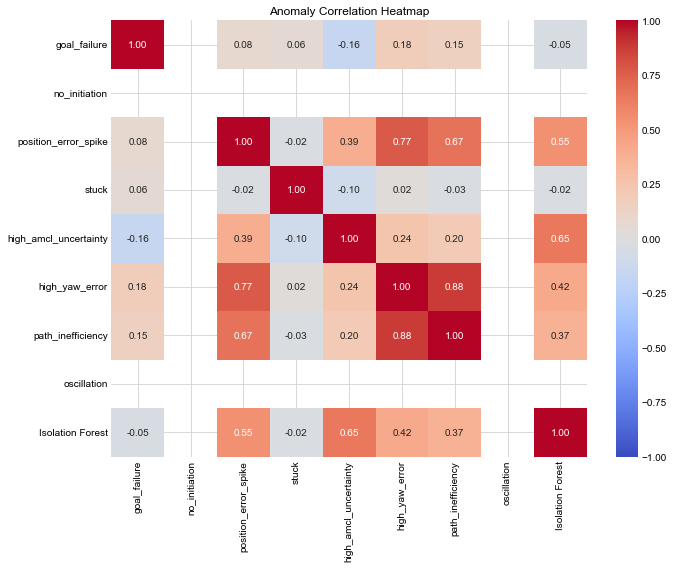

In [12]:

if valid_runs:
    anom_df_rows = []
    for run in valid_runs:
        row = {lab: 0 for lab in ANOM_LABELS}
        for a in run.anomalies or []:
            if a in row:
                row[a] = 1
        anom_df_rows.append(row)
    anom_df = pd.DataFrame(anom_df_rows)
    if anom_df.sum().sum() > 0:
        corr = anom_df.corr()
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
        plt.title('Anomaly Correlation Heatmap')
        plt.tight_layout()
        plt.savefig(IMAGES_PATH / 'anomaly_correlation_heatmap.png', dpi=150, **SAVEFIG_KW)
        plt.show()
    else:
        print('No anomalies detected to correlate.')
else:
    print('No valid runs available for anomaly correlation.')

### 9.4 Sample trajectory visualization

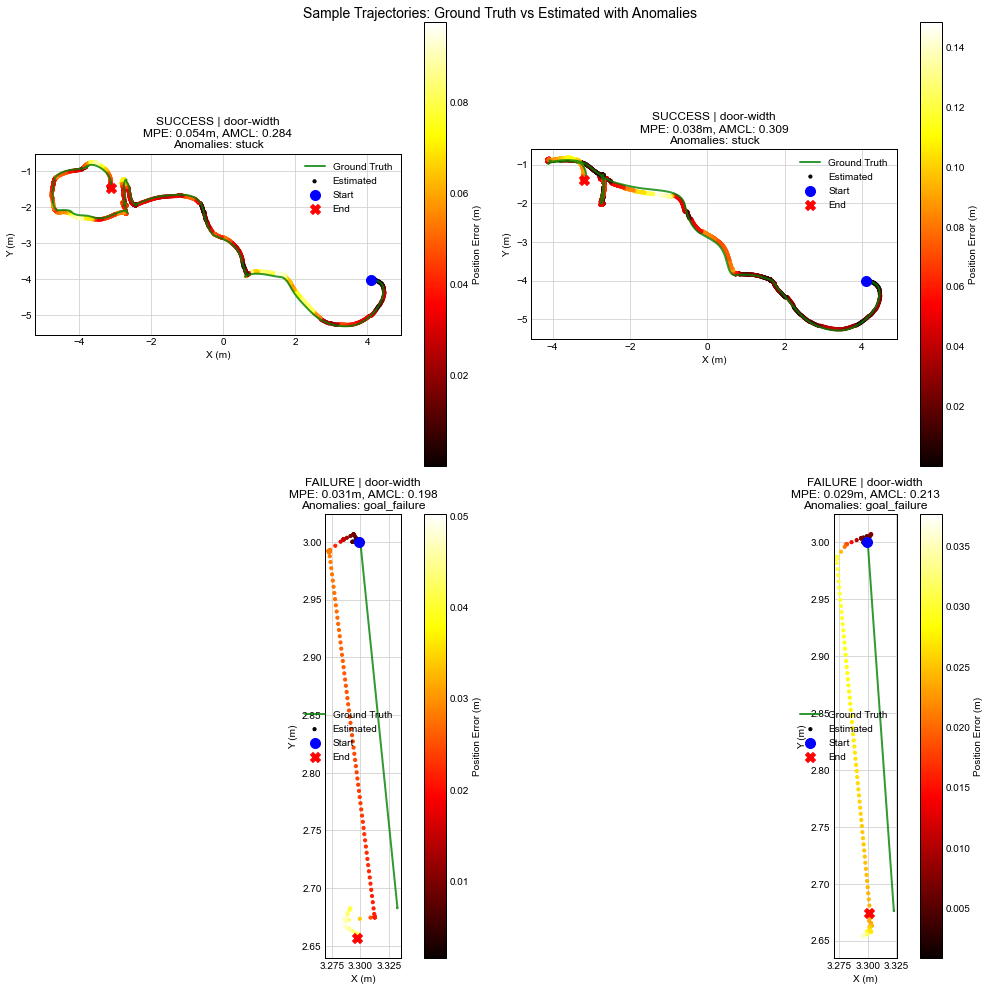

In [13]:

sample_runs = [r for r in valid_runs if r.outcome == 'success'][:2] + [r for r in valid_runs if r.outcome == 'failure'][:2]

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
for ax, run in zip(axes.flat, sample_runs):
    if run.synced_data is not None:
        synced = run.synced_data
        ax.plot(synced['gt_x'], synced['gt_y'], 'g-', linewidth=2, label='Ground Truth', alpha=0.8)
        errors = MetricCalculator.compute_position_error(synced)
        scatter = ax.scatter(synced['est_x'], synced['est_y'], c=errors, cmap='hot', s=10, label='Estimated')
        ax.scatter(synced['est_x'].iloc[0], synced['est_y'].iloc[0], c='blue', s=100, marker='o', label='Start', zorder=5)
        ax.scatter(synced['est_x'].iloc[-1], synced['est_y'].iloc[-1], c='red', s=100, marker='X', label='End', zorder=5)
        plt.colorbar(scatter, ax=ax, label='Position Error (m)')
        ax.set_xlabel('X (m)')
        ax.set_ylabel('Y (m)')
        amcl_str = f', AMCL: {run.metrics.mean_amcl_uncertainty:.3f}' if run.metrics else ''
        anom_str = f'\nAnomalies: {", ".join(run.anomalies)}' if run.anomalies else '\nNo Anomalies'
        ax.set_title(f'{run.outcome.upper()} | {run.scenario_category}\nMPE: {run.metrics.mean_pos_error:.3f}m{amcl_str}{anom_str}')
        ax.legend(loc='best')
        ax.set_aspect('equal')
plt.suptitle('Sample Trajectories: Ground Truth vs Estimated with Anomalies', fontsize=14)
plt.tight_layout()
plt.savefig(IMAGES_PATH / 'sample_trajectories.png', dpi=150, **SAVEFIG_KW)
plt.show()

## 10. Early Anomaly Prediction: Sensor & Metric Pattern Analysis

### Methodology

- **Early phase definition**: First 30% of each run's duration
- **Features extracted**: Position error statistics, velocity profiles, AMCL uncertainty, path geometry
- **Target**: Binary occurrence of each anomaly type
- **Validation**: 5-fold stratified cross-validation with PR-AUC (robust under class imbalance)

### 10.1 COMPREHENSIVE EARLY FEATURE EXTRACTION

In [14]:

EARLY_FRACTION = 0.30  # First 30% of run duration
MIN_POSITIVE_SAMPLES = 12  # Minimum positives for reliable CV

def _to_seconds(ts_like: np.ndarray) -> np.ndarray:
    """Convert timestamps to seconds (handle nanoseconds)."""
    arr = np.asarray(ts_like, dtype=float)
    med = np.nanmedian(arr) if arr.size else np.nan
    if np.isfinite(med) and med > 1e8:
        return arr / 1e9
    return arr

def _path_length_xy(x: np.ndarray, y: np.ndarray) -> float:
    """Compute path length from x,y coordinates."""
    if x is None or y is None or len(x) < 2:
        return 0.0
    return float(np.sum(np.sqrt(np.diff(x) ** 2 + np.diff(y) ** 2)))

def _smoothness_from_angular_vel(t: np.ndarray, w: np.ndarray) -> float:
    """Compute trajectory smoothness (angular acceleration)."""
    if t is None or w is None or len(t) < 3 or len(w) < 3:
        return 0.0
    dt = np.diff(t)
    dt = np.where(dt == 0, 1e-6, dt)
    dw = np.diff(w)
    acc = dw / dt[: len(dw)]
    return float(np.nanmean(np.abs(acc)))

def _amcl_uncertainty_window(amcl_data, t0_s: float, t1_s: float) -> Tuple[float, float, float, float]:
    """Extract AMCL uncertainty statistics within a time window."""
    covs = getattr(amcl_data, 'covariances', None)
    ts_attr = getattr(amcl_data, 'timestamps', None)
    if amcl_data is None or covs is None or ts_attr is None or len(ts_attr) == 0:
        return np.nan, np.nan, np.nan, np.nan
    
    amcl_t = _to_seconds(np.asarray(ts_attr, dtype=float))
    if amcl_t.size == 0:
        return np.nan, np.nan, np.nan, np.nan
    
    mask = (amcl_t >= float(t0_s)) & (amcl_t <= float(t1_s))
    idx = np.where(mask)[0]
    if idx.size == 0:
        return np.nan, np.nan, np.nan, np.nan
    
    vals = []
    for i in idx:
        try:
            cov = covs[i]
            vals.append(float(np.sqrt(cov[0, 0] + cov[1, 1])))
        except Exception:
            continue
    
    if not vals:
        return np.nan, np.nan, np.nan, np.nan
    
    return float(np.mean(vals)), float(np.max(vals)), float(np.std(vals)), float(np.median(vals))

def compute_comprehensive_early_features(run: RunData, fraction: float = 0.3) -> Optional[Dict]:
    """
    Extract comprehensive early-phase features for anomaly prediction.
    
    Features include:
    - Position error statistics (mean, max, std, trend)
    - Yaw error statistics
    - Velocity profiles (linear, angular)
    - Path geometry (length, efficiency, curvature)
    - AMCL uncertainty (mean, max, std, trend)
    - Temporal dynamics (acceleration, jerk-like measures)
    """
    if (not run.is_valid) or run.time_series_metrics is None or run.synced_data is None:
        return None
    
    ts = run.time_series_metrics.reset_index(drop=True).copy()
    synced = run.synced_data.reset_index(drop=True).copy()
    
    if len(ts) < 5 or len(synced) < 5:
        return None

    t = _to_seconds(ts['timestamp'].values)
    if not np.all(np.isfinite(t)):
        return None
    
    t0, tN = float(t[0]), float(t[-1])
    if tN <= t0:
        return None
    
    t_cut = t0 + float(fraction) * (tN - t0)
    m = t <= t_cut
    if int(m.sum()) < 3:
        n_early = max(3, int(len(ts) * fraction))
        m = np.zeros(len(ts), dtype=bool)
        m[:n_early] = True

    early_ts = ts.loc[m].copy()
    early_synced = synced.iloc[: len(early_ts)].copy()

    # Extract raw arrays
    pos_err = early_ts['pos_error'].astype(float).values
    yaw_err = early_ts['yaw_error'].astype(float).values
    lin_v = early_ts['linear_vel'].astype(float).values
    ang_v = early_ts['angular_vel'].astype(float).values
    t_e = _to_seconds(early_ts['timestamp'].values)

    # Path geometry
    est_len = _path_length_xy(early_synced['est_x'].values, early_synced['est_y'].values)
    gt_len = _path_length_xy(early_synced['gt_x'].values, early_synced['gt_y'].values)
    peff = (gt_len / est_len) if est_len > 0 else 0.0
    dur = float(t_e[-1] - t_e[0]) if len(t_e) >= 2 else 0.0
    smooth = _smoothness_from_angular_vel(t_e, ang_v)
    
    # AMCL uncertainty
    amcl_mean, amcl_max, amcl_std, amcl_med = _amcl_uncertainty_window(run.amcl_data, t_e[0], t_e[-1])
    
    # Compute trends (slope of error over time using linear regression)
    def compute_trend(values, times):
        if len(values) < 3 or len(times) < 3:
            return 0.0
        valid = np.isfinite(values) & np.isfinite(times)
        if valid.sum() < 3:
            return 0.0
        try:
            slope, _, _, _, _ = stats.linregress(times[valid], values[valid])
            return float(slope) if np.isfinite(slope) else 0.0
        except:
            return 0.0
    
    pos_err_trend = compute_trend(pos_err, t_e)
    yaw_err_trend = compute_trend(yaw_err, t_e)
    vel_trend = compute_trend(lin_v, t_e)
    
    # Velocity dynamics
    dt = np.diff(t_e)
    dt = np.where(dt == 0, 1e-6, dt)
    if len(lin_v) > 1:
        lin_acc = np.diff(lin_v) / dt[:len(lin_v)-1]
        mean_lin_acc = float(np.nanmean(np.abs(lin_acc)))
        max_lin_acc = float(np.nanmax(np.abs(lin_acc))) if len(lin_acc) > 0 else 0.0
    else:
        mean_lin_acc, max_lin_acc = 0.0, 0.0
    
    # Count zero/near-zero velocity periods (potential stuck indicators)
    stuck_ratio = float(np.sum(lin_v < 0.01) / len(lin_v)) if len(lin_v) > 0 else 0.0
    
    # Position error variability (high variance = unstable localization)
    pos_err_cv = float(np.nanstd(pos_err) / np.nanmean(pos_err)) if np.nanmean(pos_err) > 0 else 0.0
    
    # Oscillation indicator: sign changes in angular velocity
    if len(ang_v) > 2:
        ang_v_centered = ang_v - np.nanmean(ang_v)
        sign_changes = np.sum(np.diff(np.sign(ang_v_centered)) != 0)
        oscillation_freq = float(sign_changes / dur) if dur > 0 else 0.0
    else:
        oscillation_freq = 0.0

    return {
        # Identifiers
        'scenario': run.scenario_name,
        'run_id': run.run_id,
        'category': run.scenario_category,
        'outcome': run.outcome,
        'early_fraction': float(fraction),
        
        # Position error features
        'early_mean_pos_error': float(np.nanmean(pos_err)),
        'early_rmse_pos': float(np.sqrt(np.nanmean(pos_err ** 2))),
        'early_max_pos_error': float(np.nanmax(pos_err)),
        'early_std_pos_error': float(np.nanstd(pos_err)),
        'early_pos_error_trend': pos_err_trend,
        'early_pos_error_cv': pos_err_cv,
        
        # Yaw error features
        'early_mean_yaw_error': float(np.nanmean(yaw_err)),
        'early_max_yaw_error': float(np.nanmax(yaw_err)),
        'early_std_yaw_error': float(np.nanstd(yaw_err)),
        'early_yaw_error_trend': yaw_err_trend,
        
        # Path geometry features
        'early_path_length': float(est_len),
        'early_duration': float(dur),
        'early_path_efficiency': float(peff),
        
        # Velocity features
        'early_mean_velocity': float(np.nanmean(lin_v)),
        'early_max_velocity': float(np.nanmax(lin_v)),
        'early_std_velocity': float(np.nanstd(lin_v)),
        'early_velocity_trend': vel_trend,
        
        'early_mean_angular_vel': float(np.nanmean(ang_v)),
        'early_max_angular_vel': float(np.nanmax(ang_v)),
        
        # Dynamics features
        'early_smoothness': float(smooth),
        'early_mean_lin_acc': mean_lin_acc,
        'early_max_lin_acc': max_lin_acc,
        'early_stuck_ratio': stuck_ratio,
        'early_oscillation_freq': oscillation_freq,
        
        # AMCL uncertainty features
        'early_amcl_mean': float(amcl_mean) if np.isfinite(amcl_mean) else np.nan,
        'early_amcl_max': float(amcl_max) if np.isfinite(amcl_max) else np.nan,
        'early_amcl_std': float(amcl_std) if np.isfinite(amcl_std) else np.nan,
        'early_amcl_median': float(amcl_med) if np.isfinite(amcl_med) else np.nan,
    }

# Build comprehensive early feature table
print("Extracting comprehensive early-phase features...")
early_feature_rows = []
for run in tqdm(valid_runs, desc='Extracting early features'):
    row = compute_comprehensive_early_features(run, fraction=EARLY_FRACTION)
    if row is not None:
        early_feature_rows.append(row)

early_features_df = pd.DataFrame(early_feature_rows)
print(f"\nEarly feature table: {len(early_features_df)} runs with {len(early_features_df.columns)} features")

# Add anomaly labels
run_key_to_anoms = {
    (r.scenario_name, r.run_id): (r.anomalies or [])
    for r in valid_runs
}

for lab in ANOM_LABELS:
    early_features_df[f'anom__{lab}'] = early_features_df.apply(
        lambda row: int(lab in run_key_to_anoms.get((row['scenario'], int(row['run_id'])), [])),
        axis=1,
    )

# Summary of anomaly occurrences
print("\nAnomaly occurrence summary:")
for lab in ANOM_LABELS:
    count = early_features_df[f'anom__{lab}'].sum()
    pct = 100 * count / len(early_features_df)
    print(f"  {lab}: {count} ({pct:.1f}%)")

display(early_features_df.head())

Extracting comprehensive early-phase features...


Extracting early features:   0%|          | 0/300 [00:00<?, ?it/s]


Early feature table: 300 runs with 33 features

Anomaly occurrence summary:
  goal_failure: 150 (50.0%)
  no_initiation: 0 (0.0%)
  position_error_spike: 15 (5.0%)
  stuck: 115 (38.3%)
  high_amcl_uncertainty: 23 (7.7%)
  high_yaw_error: 9 (3.0%)
  path_inefficiency: 7 (2.3%)
  oscillation: 0 (0.0%)
  Isolation Forest: 45 (15.0%)


,scenario,run_id,category,outcome,early_fraction,early_mean_pos_error,early_rmse_pos,early_max_pos_error,early_std_pos_error,early_pos_error_trend,...,early_amcl_median,anom__goal_failure,anom__no_initiation,anom__position_error_spike,anom__stuck,anom__high_amcl_uncertainty,anom__high_yaw_error,anom__path_inefficiency,anom__oscillation,anom__Isolation Forest
0,small-dataset-maps-0-3-door-width-1f1-1,0,door-width,failure,0.3,0.020978,0.023363,0.028556,0.010283,0.007799,...,0.202541,1,0,0,0,0,0,0,0,0
1,small-dataset-maps-0-3-door-width-1f1-1,1,door-width,failure,0.3,0.022491,0.025164,0.030704,0.011288,0.009124,...,0.211741,1,0,0,0,0,0,0,0,0
2,small-dataset-maps-0-3-door-width-1f1-1,2,door-width,failure,0.3,0.010299,0.010670,0.012212,0.002790,0.002179,...,0.209499,1,0,0,0,0,0,0,0,0
3,small-dataset-maps-0-33-door-width-1f1-2,0,door-width,failure,0.3,0.029931,0.033473,0.040893,0.014987,0.011884,...,0.213316,1,0,0,0,0,0,0,0,0
4,small-dataset-maps-0-33-door-width-1f1-2,1,door-width,failure,0.3,0.024476,0.026004,0.030575,0.008782,0.006527,...,0.201791,1,0,0,0,0,0,0,0,0


### 10.2 CORRELATION ANALYSIS: EARLY FEATURES vs ANOMALIES

We compute **Pearson correlations** between each early-phase feature and each anomaly indicator.
This reveals which sensor/metric patterns are most associated with specific anomaly types.

Analyzing correlations between 28 features and 9 anomalies



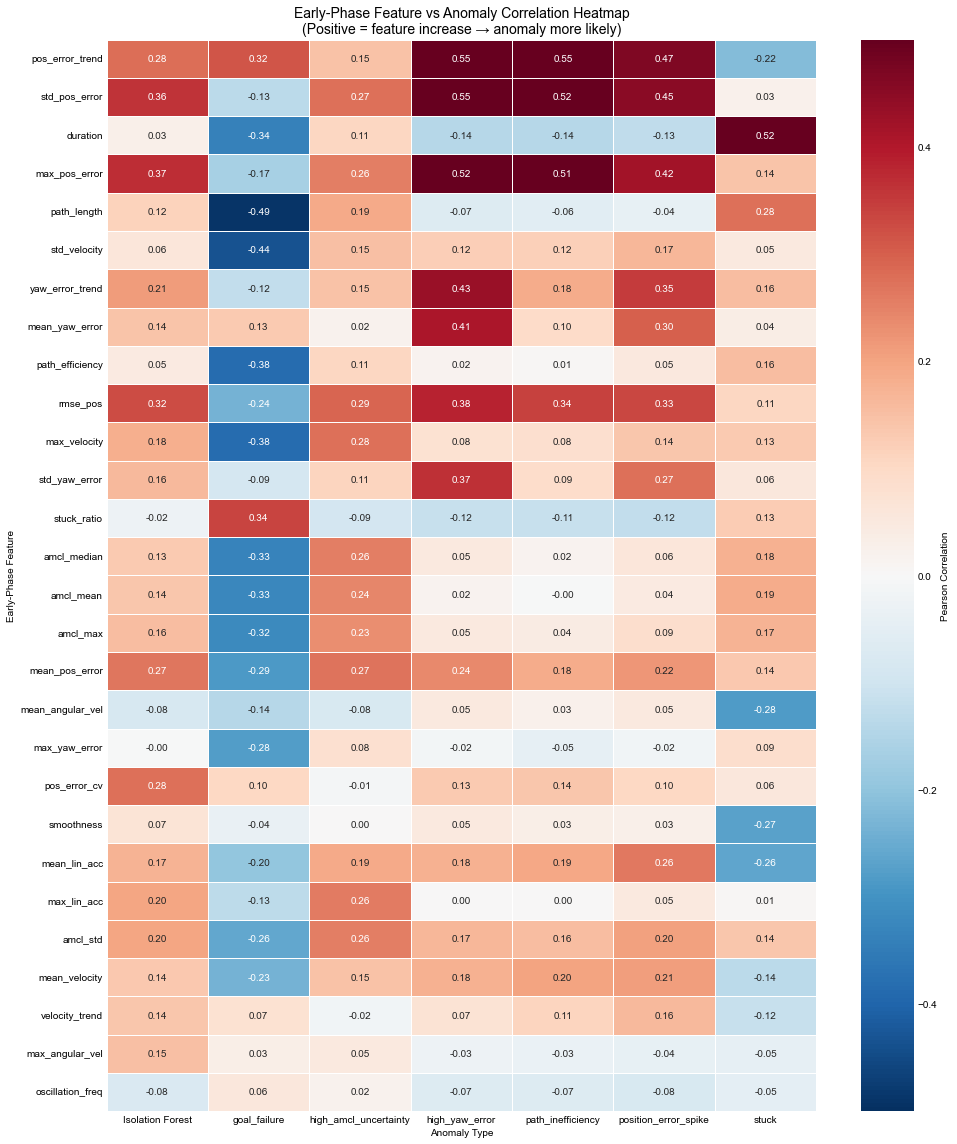


Top 5 most predictive features per anomaly (by |correlation|):

goal_failure:
  path_length                   : r=-0.491 ***
  std_velocity                  : r=-0.437 ***
  path_efficiency               : r=-0.384 ***
  max_velocity                  : r=-0.383 ***
  duration                      : r=-0.339 ***

no_initiation:
  mean_pos_error                : r=+nan 
  rmse_pos                      : r=+nan 
  max_pos_error                 : r=+nan 
  std_pos_error                 : r=+nan 
  pos_error_trend               : r=+nan 

position_error_spike:
  pos_error_trend               : r=+0.468 ***
  std_pos_error                 : r=+0.451 ***
  max_pos_error                 : r=+0.420 ***
  yaw_error_trend               : r=+0.349 ***
  rmse_pos                      : r=+0.332 ***

stuck:
  duration                      : r=+0.524 ***
  mean_angular_vel              : r=-0.283 ***
  path_length                   : r=+0.276 ***
  smoothness                    : r=-0.271 ***
  mean

In [15]:

# Define feature columns (exclude identifiers and anomaly labels)
feature_cols = [c for c in early_features_df.columns 
                if c.startswith('early_') and not c.startswith('early_fraction')]
anomaly_cols = [f'anom__{lab}' for lab in ANOM_LABELS]

print(f"Analyzing correlations between {len(feature_cols)} features and {len(anomaly_cols)} anomalies\n")

# Compute correlation matrix between features and anomalies
corr_data = []
for feat in feature_cols:
    for anom_col in anomaly_cols:
        anom_name = anom_col.replace('anom__', '')
        feat_vals = early_features_df[feat].values
        anom_vals = early_features_df[anom_col].values
        
        # Filter valid pairs
        valid = np.isfinite(feat_vals) & np.isfinite(anom_vals)
        if valid.sum() < 20:
            continue
        
        # Compute point-biserial correlation (Pearson with binary variable)
        corr, pval = stats.pearsonr(feat_vals[valid], anom_vals[valid])
        
        corr_data.append({
            'feature': feat.replace('early_', ''),
            'anomaly': anom_name,
            'correlation': corr,
            'p_value': pval,
            'significant': pval < 0.05,
            'abs_corr': abs(corr)
        })

corr_df = pd.DataFrame(corr_data)

# Create correlation heatmap
corr_pivot = corr_df.pivot_table(index='feature', columns='anomaly', values='correlation', aggfunc='mean')

# Sort features by maximum absolute correlation
feat_importance = corr_df.groupby('feature')['abs_corr'].max().sort_values(ascending=False)
corr_pivot = corr_pivot.reindex(feat_importance.index)

plt.figure(figsize=(14, 16))
mask = corr_pivot.isna()
sns.heatmap(corr_pivot, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            vmin=-0.5, vmax=0.5, mask=mask, linewidths=0.5,
            cbar_kws={'label': 'Pearson Correlation'})
plt.title('Early-Phase Feature vs Anomaly Correlation Heatmap\n(Positive = feature increase → anomaly more likely)', fontsize=14)
plt.xlabel('Anomaly Type')
plt.ylabel('Early-Phase Feature')
plt.tight_layout()
plt.savefig(IMAGES_PATH / 'early_feature_anomaly_correlation.png', dpi=150, **SAVEFIG_KW)
plt.show()

# Show top correlations per anomaly
print("\nTop 5 most predictive features per anomaly (by |correlation|):")
for anom in ANOM_LABELS:
    anom_corrs = corr_df[corr_df['anomaly'] == anom].nlargest(5, 'abs_corr')
    if len(anom_corrs) > 0:
        print(f"\n{anom}:")
        for _, row in anom_corrs.iterrows():
            sig = "***" if row['p_value'] < 0.001 else "**" if row['p_value'] < 0.01 else "*" if row['p_value'] < 0.05 else ""
            print(f"  {row['feature']:30s}: r={row['correlation']:+.3f} {sig}")

### 10.3 Predictive Modeling: Early Anomaly Detection

We train logistic regression models to predict each anomaly type from early-phase features.
Cross-validation provides robust estimates of predictive performance.

In [16]:

X_all = early_features_df[feature_cols].values

# Modeling pipeline with imputation and scaling
pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=4000, class_weight='balanced', 
                               solver='lbfgs', random_state=42)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

prediction_results = []
coefficient_data = []

print("Training predictive models for each anomaly type...\n")
print(f"{'Anomaly':<25} {'Positives':>10} {'ROC-AUC':>12} {'PR-AUC':>12} {'Predictable?':>14}")
print("-" * 75)

for lab in ANOM_LABELS:
    y_lab = early_features_df[f'anom__{lab}'].astype(int).values
    pos = int(y_lab.sum())
    neg = int(len(y_lab) - pos)
    
    if pos < MIN_POSITIVE_SAMPLES or neg < MIN_POSITIVE_SAMPLES:
        print(f"{lab:<25} {pos:>10} {'--':>12} {'--':>12} {'(insufficient)':>14}")
        continue
    
    # Cross-validated scores
    try:
        roc_scores = cross_val_score(pipe, X_all, y_lab, scoring='roc_auc', cv=cv)
        pr_scores = cross_val_score(pipe, X_all, y_lab, scoring='average_precision', cv=cv)
        
        roc_mean, roc_std = roc_scores.mean(), roc_scores.std()
        pr_mean, pr_std = pr_scores.mean(), pr_scores.std()
        
        # Determine if reliably predictable (PR-AUC > 0.3 and ROC-AUC > 0.6)
        predictable = "✓ YES" if (pr_mean > 0.3 and roc_mean > 0.6) else "partial" if roc_mean > 0.55 else "weak"
        
        prediction_results.append({
            'anomaly': lab,
            'positives': pos,
            'negatives': neg,
            'roc_auc_mean': roc_mean,
            'roc_auc_std': roc_std,
            'pr_auc_mean': pr_mean,
            'pr_auc_std': pr_std,
            'predictable': predictable
        })
        
        print(f"{lab:<25} {pos:>10} {roc_mean:>8.3f}±{roc_std:.2f} {pr_mean:>8.3f}±{pr_std:.2f} {predictable:>14}")
        
        # Extract coefficients for feature importance
        pipe.fit(X_all, y_lab)
        coefs = pipe.named_steps['clf'].coef_.ravel()
        for feat, c in zip(feature_cols, coefs):
            coefficient_data.append({
                'anomaly': lab,
                'feature': feat.replace('early_', ''),
                'coefficient': float(c),
                'abs_coef': abs(float(c))
            })
    except Exception as e:
        print(f"{lab:<25} {pos:>10} {'ERROR':>12} {'ERROR':>12} {str(e)[:14]:>14}")

prediction_df = pd.DataFrame(prediction_results)
coef_df = pd.DataFrame(coefficient_data)

print("\n" + "=" * 75)
print("PR-AUC (Precision-Recall AUC) is the primary metric for imbalanced classification.")
print("A model with PR-AUC > baseline (positive rate) indicates useful predictive signal.")

Training predictive models for each anomaly type...

Anomaly                    Positives      ROC-AUC       PR-AUC   Predictable?
---------------------------------------------------------------------------
goal_failure                     150    0.828±0.05    0.852±0.05          ✓ YES
no_initiation                      0           --           -- (insufficient)
position_error_spike              15    0.892±0.05    0.604±0.15          ✓ YES
stuck                            115    0.789±0.05    0.766±0.07          ✓ YES
high_amcl_uncertainty             23    0.757±0.07    0.321±0.10          ✓ YES
high_yaw_error                     9           --           -- (insufficient)
path_inefficiency                  7           --           -- (insufficient)
oscillation                        0           --           -- (insufficient)
Isolation Forest                  45    0.775±0.07    0.576±0.10          ✓ YES

PR-AUC (Precision-Recall AUC) is the primary metric for imbalanced classificatio

### 10.4 VISUALIZE PREDICTION PERFORMANCE

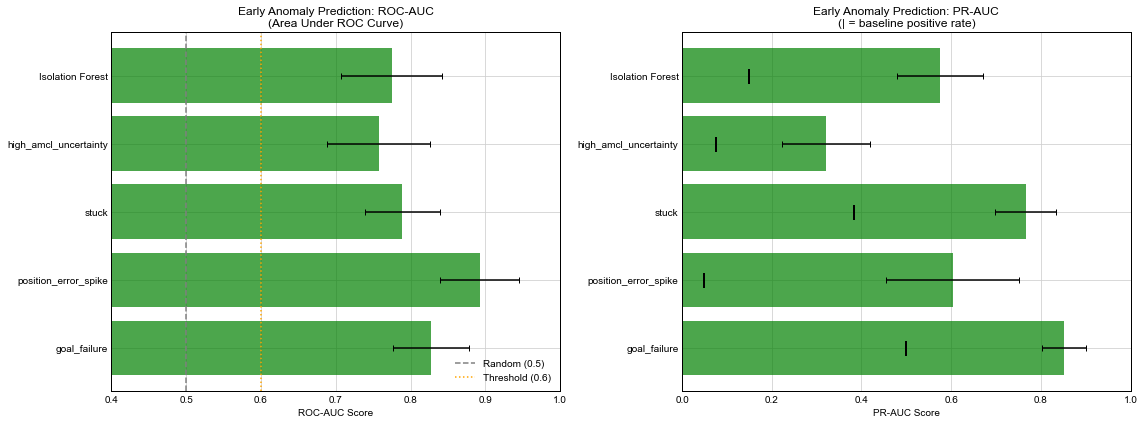


Prediction Performance Summary:


,anomaly,positives,negatives,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,predictable
0,goal_failure,150,150,0.827556,0.050968,0.851641,0.048758,✓ YES
2,stuck,115,185,0.789189,0.050013,0.765734,0.067778,✓ YES
1,position_error_spike,15,285,0.892398,0.053033,0.603835,0.148288,✓ YES
4,Isolation Forest,45,255,0.774728,0.067286,0.575783,0.095554,✓ YES
3,high_amcl_uncertainty,23,277,0.757419,0.069226,0.321126,0.098607,✓ YES


In [17]:

if len(prediction_df) > 0:
    # Bar plot of predictive performance
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # ROC-AUC
    ax = axes[0]
    colors = ['green' if p == '✓ YES' else 'orange' if p == 'partial' else 'red' 
              for p in prediction_df['predictable']]
    bars = ax.barh(prediction_df['anomaly'], prediction_df['roc_auc_mean'], 
                   xerr=prediction_df['roc_auc_std'], color=colors, alpha=0.7, capsize=3)
    ax.axvline(0.5, color='gray', linestyle='--', label='Random (0.5)')
    ax.axvline(0.6, color='orange', linestyle=':', label='Threshold (0.6)')
    ax.set_xlabel('ROC-AUC Score')
    ax.set_title('Early Anomaly Prediction: ROC-AUC\n(Area Under ROC Curve)')
    ax.set_xlim(0.4, 1.0)
    ax.legend(loc='lower right')
    
    # PR-AUC
    ax = axes[1]
    baseline_rates = prediction_df['positives'] / (prediction_df['positives'] + prediction_df['negatives'])
    ax.barh(prediction_df['anomaly'], prediction_df['pr_auc_mean'], 
            xerr=prediction_df['pr_auc_std'], color=colors, alpha=0.7, capsize=3)
    # Add baseline markers
    for i, (anom, baseline) in enumerate(zip(prediction_df['anomaly'], baseline_rates)):
        ax.plot(baseline, i, 'k|', markersize=15, markeredgewidth=2)
    ax.set_xlabel('PR-AUC Score')
    ax.set_title('Early Anomaly Prediction: PR-AUC\n(| = baseline positive rate)')
    ax.set_xlim(0, 1.0)
    
    plt.tight_layout()
    plt.savefig(IMAGES_PATH / 'early_anomaly_prediction_performance.png', dpi=150, **SAVEFIG_KW)
    plt.show()
    
    # Summary table
    print("\nPrediction Performance Summary:")
    display(prediction_df.sort_values('pr_auc_mean', ascending=False))
else:
    print("No anomalies had sufficient samples for predictive modeling.")

### 10.5 FEATURE IMPORTANCE ANALYSIS (COEFFICIENT HEATMAP)

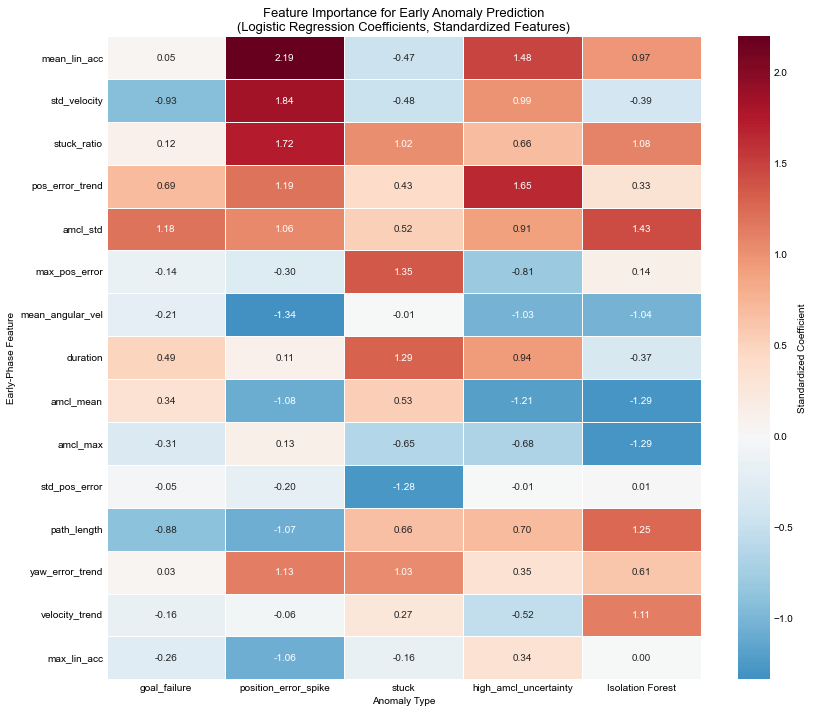


Key Feature Patterns for Anomaly Prediction:

goal_failure:
  ↑ amcl_std: coef=+1.176
  ↓ amcl_median: coef=-0.969
  ↓ std_velocity: coef=-0.930

position_error_spike:
  ↑ mean_lin_acc: coef=+2.195
  ↑ std_velocity: coef=+1.844
  ↑ stuck_ratio: coef=+1.716

stuck:
  ↑ max_pos_error: coef=+1.355
  ↑ duration: coef=+1.294
  ↓ std_pos_error: coef=-1.279

high_amcl_uncertainty:
  ↑ pos_error_trend: coef=+1.653
  ↑ mean_lin_acc: coef=+1.484
  ↓ amcl_mean: coef=-1.210

Isolation Forest:
  ↑ amcl_std: coef=+1.435
  ↓ amcl_mean: coef=-1.290
  ↓ amcl_max: coef=-1.289


In [18]:

if len(coef_df) > 0:
    # Create coefficient heatmap
    coef_pivot = coef_df.pivot_table(index='feature', columns='anomaly', 
                                      values='coefficient', aggfunc='mean')
    
    # Sort features by maximum absolute coefficient
    feat_max_coef = coef_df.groupby('feature')['abs_coef'].max().sort_values(ascending=False)
    top_features = feat_max_coef.head(15).index.tolist()
    coef_pivot_top = coef_pivot.reindex(top_features)
    
    # Only include anomalies with models
    modeled_anoms = prediction_df['anomaly'].tolist()
    coef_pivot_top = coef_pivot_top[[a for a in modeled_anoms if a in coef_pivot_top.columns]]
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(coef_pivot_top, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                linewidths=0.5, cbar_kws={'label': 'Standardized Coefficient'})
    plt.title('Feature Importance for Early Anomaly Prediction\n(Logistic Regression Coefficients, Standardized Features)', 
              fontsize=13)
    plt.xlabel('Anomaly Type')
    plt.ylabel('Early-Phase Feature')
    plt.tight_layout()
    plt.savefig(IMAGES_PATH / 'early_anomaly_feature_importance.png', dpi=150, **SAVEFIG_KW)
    plt.show()
    
    # Print interpretation
    print("\nKey Feature Patterns for Anomaly Prediction:")
    print("=" * 70)
    
    for anom in modeled_anoms[:6]:  # Top 6 most predictable
        anom_coefs = coef_df[coef_df['anomaly'] == anom].nlargest(3, 'abs_coef')
        if len(anom_coefs) > 0:
            print(f"\n{anom}:")
            for _, row in anom_coefs.iterrows():
                direction = "↑" if row['coefficient'] > 0 else "↓"
                print(f"  {direction} {row['feature']}: coef={row['coefficient']:+.3f}")

### 10.6 Anomaly Co-occurrence ANALYSIS

Understanding which anomalies tend to occur together can reveal shared underlying causes
and improve joint prediction strategies.

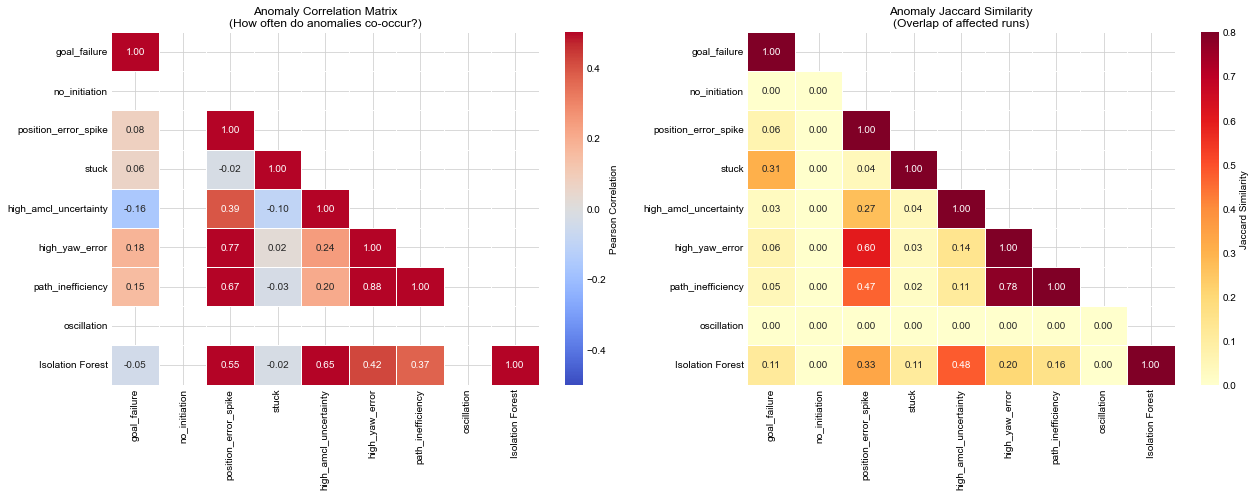


Strong Anomaly Co-occurrences (Jaccard > 0.3):
  goal_failure <-> stuck: Jaccard=0.31 (62 runs)
  position_error_spike <-> high_yaw_error: Jaccard=0.60 (9 runs)
  position_error_spike <-> path_inefficiency: Jaccard=0.47 (7 runs)
  position_error_spike <-> Isolation Forest: Jaccard=0.33 (15 runs)
  high_amcl_uncertainty <-> Isolation Forest: Jaccard=0.48 (22 runs)
  high_yaw_error <-> path_inefficiency: Jaccard=0.78 (7 runs)


In [19]:

# Build binary anomaly matrix
anom_binary_cols = [f'anom__{lab}' for lab in ANOM_LABELS]
anom_matrix = early_features_df[anom_binary_cols].copy()
anom_matrix.columns = ANOM_LABELS

# Compute co-occurrence matrix (Jaccard similarity)
def jaccard_similarity(a, b):
    intersection = np.sum((a == 1) & (b == 1))
    union = np.sum((a == 1) | (b == 1))
    return intersection / union if union > 0 else 0

jaccard_matrix = np.zeros((len(ANOM_LABELS), len(ANOM_LABELS)))
for i, lab1 in enumerate(ANOM_LABELS):
    for j, lab2 in enumerate(ANOM_LABELS):
        jaccard_matrix[i, j] = jaccard_similarity(
            anom_matrix[lab1].values, 
            anom_matrix[lab2].values
        )

jaccard_df = pd.DataFrame(jaccard_matrix, index=ANOM_LABELS, columns=ANOM_LABELS)

# Create two subplots: Correlation and Jaccard similarity
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Pearson correlation (how anomaly presence correlates)
ax = axes[0]
anom_corr = anom_matrix.corr()
mask = np.triu(np.ones_like(anom_corr, dtype=bool), k=1)
sns.heatmap(anom_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-0.5, vmax=0.5, mask=mask, ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Pearson Correlation'})
ax.set_title('Anomaly Correlation Matrix\n(How often do anomalies co-occur?)', fontsize=12)

# 2. Jaccard similarity (overlap of affected runs)
ax = axes[1]
mask = np.triu(np.ones_like(jaccard_df, dtype=bool), k=1)
sns.heatmap(jaccard_df, annot=True, fmt='.2f', cmap='YlOrRd',
            vmin=0, vmax=0.8, mask=mask, ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Jaccard Similarity'})
ax.set_title('Anomaly Jaccard Similarity\n(Overlap of affected runs)', fontsize=12)

plt.tight_layout()
plt.savefig(IMAGES_PATH / 'anomaly_cooccurrence_patterns.png', dpi=150, **SAVEFIG_KW)
plt.show()

# Identify strong co-occurrences
print("\nStrong Anomaly Co-occurrences (Jaccard > 0.3):")
for i, lab1 in enumerate(ANOM_LABELS):
    for j, lab2 in enumerate(ANOM_LABELS):
        if i < j and jaccard_matrix[i, j] > 0.3:
            n_both = int(np.sum((anom_matrix[lab1] == 1) & (anom_matrix[lab2] == 1)))
            print(f"  {lab1} <-> {lab2}: Jaccard={jaccard_matrix[i,j]:.2f} ({n_both} runs)")

### 10.7 COMPREHENSIVE EARLY PREDICTION SUMMARY

In [20]:

print("=" * 80)
print("EARLY ANOMALY PREDICTION SUMMARY")
print("=" * 80)

print(f"\n1. DATASET OVERVIEW")
print(f"   - Total valid runs analyzed: {len(early_features_df)}")
print(f"   - Early phase fraction: {EARLY_FRACTION:.0%} of run duration")
print(f"   - Features extracted: {len(feature_cols)}")
print(f"   - Anomaly types: {len(ANOM_LABELS)}")

print(f"\n2. MOST PREDICTABLE ANOMALIES (by PR-AUC)")
if len(prediction_df) > 0:
    for _, row in prediction_df.nlargest(5, 'pr_auc_mean').iterrows():
        print(f"   - {row['anomaly']}: PR-AUC={row['pr_auc_mean']:.3f}, "
              f"ROC-AUC={row['roc_auc_mean']:.3f} ({row['positives']} cases)")

print(f"\n3. KEY PREDICTIVE PATTERNS")
print("   Early indicators that robustly predict anomalies:")

# Summarize top patterns from correlation analysis
key_patterns = corr_df[corr_df['significant']].nlargest(10, 'abs_corr')
for _, row in key_patterns.iterrows():
    direction = "Higher" if row['correlation'] > 0 else "Lower"
    print(f"   - {direction} early {row['feature']} → {row['anomaly']} (r={row['correlation']:+.3f})")

print(f"\n4. ANOMALY CO-OCCURRENCE CLUSTERS")
print("   Anomalies that tend to occur together (shared root causes):")
clusters_found = False
for i, lab1 in enumerate(ANOM_LABELS):
    for j, lab2 in enumerate(ANOM_LABELS):
        if i < j and jaccard_matrix[i, j] > 0.4:
            clusters_found = True
            print(f"   - {lab1} + {lab2} (Jaccard={jaccard_matrix[i,j]:.2f})")
if not clusters_found:
    print("   - No strong clusters found (Jaccard > 0.4)")

print(f"\n5. RECOMMENDATIONS FOR EARLY INTERVENTION")
print("   Based on the analysis, monitor these early signals:")
print("   - Position error trend (rising = potential localization failure)")
print("   - AMCL uncertainty (high values = poor localization confidence)")
print("   - Stuck ratio (high = potential immobilization)")
print("   - Velocity variability (high std = control instability)")
print("   - Oscillation frequency (high = potential path planning issues)")

print("\n" + "=" * 80)

EARLY ANOMALY PREDICTION SUMMARY

1. DATASET OVERVIEW
   - Total valid runs analyzed: 300
   - Early phase fraction: 30% of run duration
   - Features extracted: 28
   - Anomaly types: 9

2. MOST PREDICTABLE ANOMALIES (by PR-AUC)
   - goal_failure: PR-AUC=0.852, ROC-AUC=0.828 (150 cases)
   - stuck: PR-AUC=0.766, ROC-AUC=0.789 (115 cases)
   - position_error_spike: PR-AUC=0.604, ROC-AUC=0.892 (15 cases)
   - Isolation Forest: PR-AUC=0.576, ROC-AUC=0.775 (45 cases)
   - high_amcl_uncertainty: PR-AUC=0.321, ROC-AUC=0.757 (23 cases)

3. KEY PREDICTIVE PATTERNS
   Early indicators that robustly predict anomalies:
   - Higher early pos_error_trend → path_inefficiency (r=+0.555)
   - Higher early pos_error_trend → high_yaw_error (r=+0.550)
   - Higher early std_pos_error → high_yaw_error (r=+0.545)
   - Higher early duration → stuck (r=+0.524)
   - Higher early std_pos_error → path_inefficiency (r=+0.521)
   - Higher early max_pos_error → high_yaw_error (r=+0.519)
   - Higher early max_pos_e